In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Load dataset
data =pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")


# Clean up Price column (remove INR and commas)
def clean_price(x):
    if pd.isna(x): return None
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    try:
        return float(x)
    except:
        return None

data['Launched Price (India)'] = data['Launched Price (India)'].apply(clean_price)
data.rename(columns={'Launched Price (India)': 'Price_INR'}, inplace=True)


In [21]:
def extract_ram(x):
    if pd.isna(x): 
        return None
    match = re.search(r'(\d+(\.\d+)?)', str(x))
    return float(match.group(1)) if match else None

data['RAM_GB'] = data['RAM'].apply(extract_ram)


In [23]:
from pathlib import Path
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)


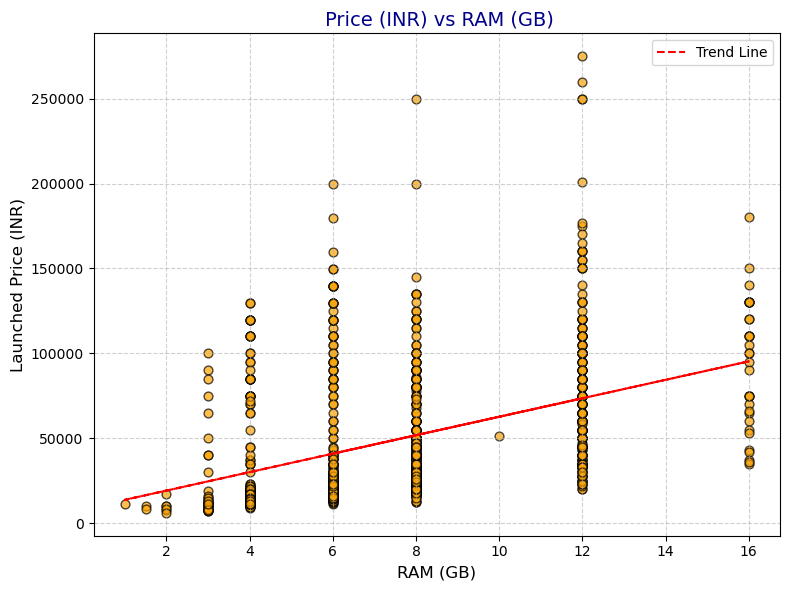

In [27]:
plt.figure(figsize=(8,6))
subset = data.dropna(subset=['Price_INR','RAM_GB'])
plt.scatter(subset['RAM_GB'], subset['Price_INR'], s=40, c='orange', edgecolor='black', alpha=0.7)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Launched Price (INR)', fontsize=12)
plt.title(' Price (INR) vs RAM (GB)', fontsize=14, color='darkblue')
plt.grid(True, linestyle='--', alpha=0.6)

# Add trend line for clarity
z = np.polyfit(subset['RAM_GB'], subset['Price_INR'], 1)
p = np.poly1d(z)
plt.plot(subset['RAM_GB'], p(subset['RAM_GB']), color='red', linestyle='--', label='Trend Line')
plt.legend()

plt.tight_layout()
plt.savefig(out_dir / "price_vs_ram.png")
plt.show()
